# Austin 2024 Validation
## Modulo C - Test con dati reali


In [1]:
import sys
sys.path.append('..')

from src.data.austin_loader import AustinDataLoader
from src.data.feature_extractor import FeatureExtractor
from src.strategy.predictor import RacePredictor

import warnings
warnings.filterwarnings('ignore')

## STEP 1: Carica Dati

In [2]:
loader = AustinDataLoader()
sessions = loader.load_all_sessions()

📥 Caricamento dati Austin 2024...
  ⏳ FP1...

events      WARNING 	Correcting user input 'United States' to 'United States Grand Prix'
core           INFO 	Loading data for United States Grand Prix - Practice 1 [v3.6.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '4', '10', '11', '14', '16', '18', '20', '22', '23', '24', '27', '30', '31', '43', '44', '55', '63', '77', '81']
events      

 ✅
  ⏳ SprintQuali...

req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '63', '16', '4', '55', '27', '44', '20', '22', '43', '11', '10', '18', '14', '30', '81', '31', '23', '77', '24']
events      WARNING 	Correcting user input 'United States' to 'United States Grand Prix'
core           INFO 	Loading data for United States Grand Prix - Sprint [v3.6.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core      

 ✅
  ⏳ Sprint...

...

 ✅
  ⏳ Quali...

req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['4', '1', '55', '16', '81', '63', '10', '14', '20', '11', '22', '27', '31', '18', '30', '23', '43', '77', '44', '24']
events      WARNING 	Correcting user input 'United States' to 'United States Grand Prix'
core           INFO 	Loading data for United States Grand Prix - Race [v3.6.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core        

 ✅
  ⏳ Race...

req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['16', '55', '1', '4', '81', '63', '11', '27', '30', '43', '20', '10', '14', '22', '18', '23', '77', '31', '24', '44']


 ✅
✅ Sessioni caricate!



In [3]:
actual_results = loader.get_race_results()
pit_stops = loader.get_pit_stops()

🏁 RISULTATO REALE Austin 2024:
  Abbreviation  Position  GridPosition                   Time  Points
0          LEC       1.0           4.0 0 days 01:35:09.639000    25.0
1          SAI       2.0           3.0 0 days 00:00:08.562000    18.0
2          VER       3.0           2.0 0 days 00:00:19.412000    15.0
3          NOR       4.0           1.0 0 days 00:00:20.354000    12.0
4          PIA       5.0           5.0 0 days 00:00:21.921000    10.0
5          RUS       6.0          20.0 0 days 00:00:56.295000     8.0
6          PER       7.0           9.0 0 days 00:00:59.072000     6.0
7          HUL       8.0          11.0 0 days 00:01:02.957000     4.0
8          LAW       9.0          19.0 0 days 00:01:10.563000     2.0
9          COL      10.0          15.0 0 days 00:01:11.979000     1.0

🔧 PIT STOPS REALI:
   Driver  PitLap Compound  TyreAge
9     ALB     3.0   MEDIUM        0
11    ZHO    13.0   MEDIUM        0
21    BOT    15.0   MEDIUM        0
6     MAG    17.0   MEDIUM        0

## STEP 2: Estrai Features

In [4]:
extractor = FeatureExtractor(sessions)
grid_df = extractor.create_grid_dataframe()
grid_df.head(10)

📊 Usando Sprint per pace


UnboundLocalError: cannot access local variable 'laps' where it is not associated with a value

## STEP 3: Predici Gara

In [5]:
predictor = RacePredictor(track_name='AUSTIN')
predictions = predictor.predict_race(grid_df)


🏎️  AVVIO PREDIZIONE GARA

🔍 Ottimizzazione strategia pit stop...
  ✅ Strategia assegnata (range giri: 23-27)
🚦 Gara Inizializzata con 20 piloti.
🏁 STARTING GLOBAL SIMULATION (Fixed Overtake Logic)...
   ⚠️ CONFLITTO SAI: Ritardo sosta (+1 giro)

🏁 PREDIZIONE FINALE
 PredictedPosition Driver  GapToLeader
                 1    LEC        0.000
                 2    STR        1.432
                 3    SAI       14.512
                 4    ALO       16.656
                 5    VER       61.704
                 6    RUS       76.960
                 7    PIA       99.580
                 8    GAS      101.612
                 9    OCO      103.604
                10    COL      104.800



## STEP 4: Validazione

In [6]:
comparison = predictor.compare_with_actual(predictions, actual_results)


📊 VALIDAZIONE: Predetto vs Reale

Driver  ActualPosition  PredictedPosition  Error
   LEC             1.0                  1    0.0
   SAI             2.0                  3    1.0
   VER             3.0                  5    2.0
   NOR             4.0                 19   15.0
   PIA             5.0                  7    2.0
   RUS             6.0                  6    0.0
   PER             7.0                 18   11.0
   HUL             8.0                 12    4.0
   LAW             9.0                 20   11.0
   COL            10.0                 10    0.0

📈 METRICHE:
  • MAE (Mean Absolute Error): 4.60 posizioni
  • Top 3 esatti: 1/3
  • Top 10 entro 1 pos: 4/10


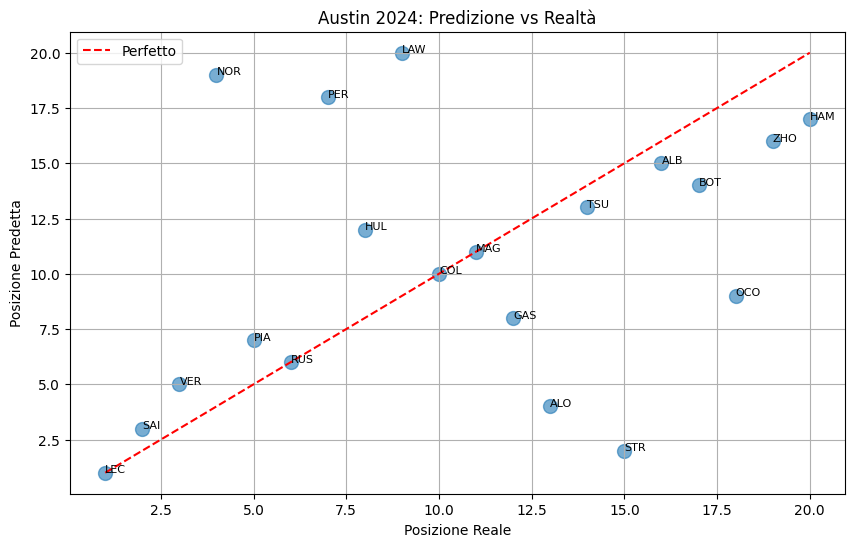

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(comparison['ActualPosition'], comparison['PredictedPosition'], s=100, alpha=0.6)
ax.plot([1, 20], [1, 20], 'r--', label='Perfetto')

for _, row in comparison.iterrows():
    ax.annotate(row['Driver'], (row['ActualPosition'], row['PredictedPosition']), fontsize=8)

ax.set_xlabel('Posizione Reale')
ax.set_ylabel('Posizione Predetta')
ax.set_title('Austin 2024: Predizione vs Realtà')
ax.legend()
ax.grid(True)
plt.show()